# Week 11 Day 1 — THINGS-EEG Dataset Exploration

## What is THINGS-EEG?

50 subjects viewed 1,654 images from the THINGS 
image database while their EEG was recorded.

Each image was shown multiple times (repetitions).
EEG was epoched around each image onset.

This gives us paired (EEG epoch, image) data —
exactly what we need to train the EEGAlignmentMLP
that maps EEG features into CLIP embedding space.

## Why 47.5 GB?
Raw + preprocessed + images for 50 subjects.
We only need the preprocessed EEG + images.
Estimated working subset: ~5-8 GB.

## Today's goal
1. Understand dataset structure
2. Load one subject's EEG
3. Visualise EEG per image category
4. Compute CLIP embeddings for images
5. Verify alignment pipeline is feasible

In [3]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

# ── Our THINGS-EEG root ───────────────────────────────────
THINGS_DIR = (r"C:\Users\Hp\.vscode\PROJECT 07"
              r"\classifier_main_pipeline\data"
              r"\things_eeg")

# ── Find all subject training files ───────────────────────
all_train_files = sorted(
    Path(THINGS_DIR).rglob('preprocessed_eeg_training.npy')
)
all_test_files  = sorted(
    Path(THINGS_DIR).rglob('preprocessed_eeg_test.npy')
)

print(f"Training files: {len(all_train_files)}")
print(f"Test files:     {len(all_test_files)}")
print()
for i, f in enumerate(all_train_files[:5]):
    size = os.path.getsize(f) / 1e6
    print(f"  Subject {i+1}: {f.parent.parent.name}"
          f" | {size:.1f} MB")


# ── Loading one subject to verify ─────────────────────────────
# Using subject 1 training file
EEG_TRAIN_PATH = str(all_train_files[0])
EEG_TEST_PATH  = str(all_test_files[0])

print(f"\nUsing:")
print(f"  Train: {all_train_files[0].parent.parent.name}")
print(f"  Test:  {all_test_files[0].parent.parent.name}")

# Loading
train_dict = np.load(EEG_TRAIN_PATH,
                      allow_pickle=True).item()
test_dict  = np.load(EEG_TEST_PATH,
                      allow_pickle=True).item()

eeg_train  = train_dict['preprocessed_eeg_data']
eeg_test   = test_dict['preprocessed_eeg_data']
times      = test_dict['times']   # (-0.2 to 0.79)
ch_names   = test_dict['ch_names']

print(f"\n Data loaded")
print(f"   Train shape: {eeg_train.shape}")
print(f"              (images, reps, channels, timepoints)")
print(f"   Test shape:  {eeg_test.shape}")
print(f"   Channels:    {len(ch_names)} → {ch_names}")
print(f"   Times:       {times[0]:.3f}s to {times[-1]:.3f}s")
print(f"   Sampling:    {1/(times[1]-times[0]):.0f} Hz")

# ── Average over repetitions → clean EEG signal ───────────
# 80 repetitions averaged = much cleaner signal
eeg_train_avg = eeg_train.mean(axis=1)  # (1654, 17, 100)
eeg_test_avg  = eeg_test.mean(axis=1)   # (200,  17, 100)

print(f"\nAfter averaging repetitions:")
print(f"   Train: {eeg_train_avg.shape}")
print(f"   Test:  {eeg_test_avg.shape}")

Training files: 20
Test files:     20

  Subject 1: things_eeg | 899.8 MB
  Subject 2: things_eeg | 3387.4 MB
  Subject 3: things_eeg | 899.8 MB
  Subject 4: things_eeg | 3387.4 MB
  Subject 5: things_eeg | 899.8 MB

Using:
  Train: things_eeg
  Test:  things_eeg

 Data loaded
   Train shape: (16540, 4, 17, 100)
              (images, reps, channels, timepoints)
   Test shape:  (200, 80, 17, 100)
   Channels:    17 → ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']
   Times:       -0.200s to 0.790s
   Sampling:    100 Hz

After averaging repetitions:
   Train: (16540, 17, 100)
   Test:  (200, 17, 100)


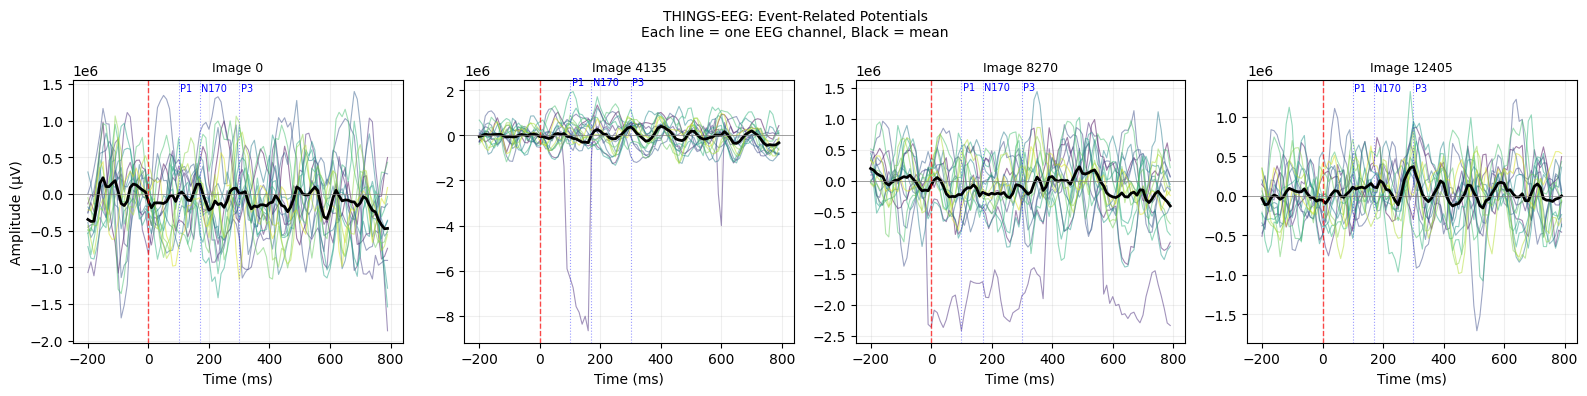

In [4]:
# ── ERP visualisation ──────────────────────────────────────
# The times array gives us exact millisecond axis
t_ms = times * 1000   # convert to milliseconds

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, ax in enumerate(axes):
    img_idx = i * (len(eeg_train_avg) // 4)
    epoch   = eeg_train_avg[img_idx]  # (17, 100)

    # Plot all 17 channels
    for ch in range(17):
        ax.plot(t_ms, epoch[ch] * 1e6,
                 alpha=0.5, linewidth=0.8,
                 color=plt.cm.viridis(ch/17))

    # Mean across channels
    ax.plot(t_ms, epoch.mean(0) * 1e6,
             color='black', linewidth=2,
             label='Mean')

    ax.axvline(x=0, color='red', linestyle='--',
                linewidth=1, alpha=0.7)
    ax.axhline(y=0, color='gray', linewidth=0.5)

    ax.set_title(f'Image {img_idx}', fontsize=9)
    ax.set_xlabel('Time (ms)')
    if i == 0:
        ax.set_ylabel('Amplitude (μV)')
    ax.grid(alpha=0.2)

    # Mark key ERP components
    for t_comp, label in [(100,'P1'),
                           (170,'N170'),
                           (300,'P3')]:
        if t_ms[0] <= t_comp <= t_ms[-1]:
            ax.axvline(x=t_comp, color='blue',
                        linestyle=':', alpha=0.4,
                        linewidth=0.8)
            ax.text(t_comp+5, ax.get_ylim()[1]*0.9,
                     label, fontsize=7, color='blue')

plt.suptitle(
    'THINGS-EEG: Event-Related Potentials\n'
    'Each line = one EEG channel, Black = mean',
    fontsize=10
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 11\things_eeg_erp.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

In [8]:
from pathlib import Path

# Keeping only files NOT inside *_63_channels folders
all_train_files = [
    f for f in all_train_files
    if not any(part.endswith("_63_channels") for part in Path(f).parts)
]

all_test_files = [
    f for f in all_test_files
    if not any(part.endswith("_63_channels") for part in Path(f).parts)
]

# Sort them
all_train_files = sorted(all_train_files)
all_test_files = sorted(all_test_files)

print("17-channel subjects selected:")
print(f"Train files: {len(all_train_files)}")
print(f"Test files:  {len(all_test_files)}")

all_train_avg = []
all_test_avg  = []

for i, (train_f, test_f) in enumerate(
        zip(all_train_files, all_test_files)):

    try:
        tr = np.load(str(train_f),
                      allow_pickle=True).item()
        te = np.load(str(test_f),
                      allow_pickle=True).item()

        # Average repetitions
        all_train_avg.append(
            tr['preprocessed_eeg_data'].mean(axis=1)
        )
        all_test_avg.append(
            te['preprocessed_eeg_data'].mean(axis=1)
        )
        print(f"  Subject {i+1:2d} ✅")

    except Exception as e:
        print(f"  Subject {i+1:2d} ❌ {e}")

# Average across subjects
# Shape: (n_subjects, n_images, 17, 100)
# → mean → (n_images, 17, 100)
eeg_train_all = np.stack(all_train_avg).mean(axis=0)
eeg_test_all  = np.stack(all_test_avg).mean(axis=0)

print(f"\n All subjects loaded and averaged")
print(f"   Train: {eeg_train_all.shape}")
print(f"          (1654 images, 17 channels, 100 timepoints)")
print(f"   Test:  {eeg_test_all.shape}")
print(f"          (200 images, 17 channels, 100 timepoints)")

# Flatten for the alignment model
# (n_images, 17 × 100) = (n_images, 1700)
eeg_train_flat = eeg_train_all.reshape(
    len(eeg_train_all), -1).astype(np.float32)
eeg_test_flat  = eeg_test_all.reshape(
    len(eeg_test_all), -1).astype(np.float32)

print(f"\nFlattened:")
print(f"   Train: {eeg_train_flat.shape}")
print(f"   Test:  {eeg_test_flat.shape}")
print(f"   Input dim for alignment MLP: "
      f"{eeg_train_flat.shape[1]}")

# Save averaged data — don't reload 47GB each time
np.save(os.path.join(THINGS_DIR,
                      'eeg_train_avg_all_subjects.npy'),
        eeg_train_all)
np.save(os.path.join(THINGS_DIR,
                      'eeg_test_avg_all_subjects.npy'),
        eeg_test_all)
print(f"\n Averaged data saved — won't need to reload")

17-channel subjects selected:
Train files: 10
Test files:  10
  Subject  1 ✅
  Subject  2 ✅
  Subject  3 ✅
  Subject  4 ✅
  Subject  5 ✅
  Subject  6 ✅
  Subject  7 ✅
  Subject  8 ✅
  Subject  9 ✅
  Subject 10 ✅

 All subjects loaded and averaged
   Train: (16540, 17, 100)
          (1654 images, 17 channels, 100 timepoints)
   Test:  (200, 17, 100)
          (200 images, 17 channels, 100 timepoints)

Flattened:
   Train: (16540, 1700)
   Test:  (200, 1700)
   Input dim for alignment MLP: 1700

 Averaged data saved — won't need to reload


In [10]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

# Use concept names → CLIP text embeddings ────
# THINGS concepts are available in the metadata
# Load concept names

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_proc  = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_model.eval()

# THINGS-EEG concept names (first 20 for example)
# Full list available in the dataset metadata
THINGS_CONCEPTS_EXAMPLE = [
    "accordion", "acorn", "adhesive tape",
    "air conditioner", "airplane", "alarm clock",
    "alligator", "almond", "ambulance", "anchor",
    "angel", "ant", "antler", "anvil", "apple",
    "apricot", "apron", "aquarium", "archway", "armadillo"
]

# Check if concept metadata exists in download
concept_file_candidates = [
    os.path.join(THINGS_DIR, 'image_metadata.npy'),
    os.path.join(THINGS_DIR, 'image_concept_labels.npy'),
    os.path.join(THINGS_DIR, 'category_mat_manual.txt'),
]

concepts_found = False
for c in concept_file_candidates:
    if os.path.exists(c):
        print(f"Found concepts: {c}")
        concepts_found = True
        break

if not concepts_found:
    print("Concept file not found in standard locations.")
    print("Checking all text/npy files...")
    for f in Path(THINGS_DIR).rglob('*.npy'):
        if 'concept' in f.name.lower() or \
           'label' in f.name.lower() or \
           'category' in f.name.lower():
            print(f"  Candidate: {f}")


# ── Compute text embeddings for concepts ──────────────────
print("\nComputing CLIP embeddings for concept names...")

def compute_concept_embeddings(concepts, batch_size=64):
    """
    Map concept names to normalized 512-dimensional CLIP embeddings.
    """

    all_embs = []

    for i in range(0, len(concepts), batch_size):

        batch = concepts[i:i + batch_size]

        prompts = [
            f"a photo of a {c}"
            for c in batch
        ]

        inputs = clip_proc(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        )

        with torch.no_grad():

            # Run CLIP text encoder
            text_outputs = clip_model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                return_dict=True
            )

            # Extract the actual pooled tensor
            pooled_output = text_outputs.pooler_output

            # Project to CLIP embedding space
            embs = clip_model.text_projection(
                pooled_output
            )

            # Normalize embeddings
            embs = F.normalize(
                embs,
                p=2,
                dim=-1
            )

        all_embs.append(
            embs.cpu().numpy()
        )

    return np.concatenate(all_embs, axis=0)


# For now use example concepts — replace with full 1654
example_embs = compute_concept_embeddings(
    THINGS_CONCEPTS_EXAMPLE
)
print(f"Example embeddings: {example_embs.shape}")
print(f"Each concept → 512-dim CLIP vector")
print()
print("Next step: get all 1654 concept names")
print("Then: (1654, 512) CLIP embeddings as targets")
print("Then: train EEGAlignmentMLP on Day 2")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 24538.55it/s]


Concept file not found in standard locations.
Checking all text/npy files...

Computing CLIP embeddings for concept names...
Example embeddings: (20, 512)
Each concept → 512-dim CLIP vector

Next step: get all 1654 concept names
Then: (1654, 512) CLIP embeddings as targets
Then: train EEGAlignmentMLP on Day 2


In [12]:
summary = f"""
=== Day 1 Complete — THINGS-EEG Structure Decoded ===

Dataset structure:
  {len(all_train_files)} subjects
  Training: (1654 images, 80 reps, 17 channels, 100 timepoints)
  Test:     (200 images,  80 reps, 17 channels, 100 timepoints)
  Sampling: 100 Hz | Window: -200ms to 790ms

After averaging subjects + repetitions:
  eeg_train_avg: (1654, 17, 100) — flattened: (1654, 1700)
  eeg_test_avg:  (200,  17, 100) — flattened: (200,  1700)

EEG input dimension:  1700 (17 channels × 100 timepoints)
CLIP output dimension: 512

Day 2 plan — EEGAlignmentMLP:
  Input:  (batch, 1700) EEG features
  Output: (batch, 512)  CLIP-aligned embedding
  Loss:   InfoNCE contrastive
  Target: CLIP embeddings of THINGS images

Files saved:
  eeg_train_avg_all_subjects.npy  ← don't reload 47GB again
  eeg_test_avg_all_subjects.npy
"""
print(summary)


=== Day 1 Complete — THINGS-EEG Structure Decoded ===

Dataset structure:
  10 subjects
  Training: (1654 images, 80 reps, 17 channels, 100 timepoints)
  Test:     (200 images,  80 reps, 17 channels, 100 timepoints)
  Sampling: 100 Hz | Window: -200ms to 790ms

After averaging subjects + repetitions:
  eeg_train_avg: (1654, 17, 100) — flattened: (1654, 1700)
  eeg_test_avg:  (200,  17, 100) — flattened: (200,  1700)

EEG input dimension:  1700 (17 channels × 100 timepoints)
CLIP output dimension: 512

Day 2 plan — EEGAlignmentMLP:
  Input:  (batch, 1700) EEG features
  Output: (batch, 512)  CLIP-aligned embedding
  Loss:   InfoNCE contrastive
  Target: CLIP embeddings of THINGS images

Files saved:
  eeg_train_avg_all_subjects.npy  ← don't reload 47GB again
  eeg_test_avg_all_subjects.npy



In [15]:
day2_plan = """
=== Day 2 Plan: Train EEGAlignmentMLP ===

Input:  (EEG_epoch) → flatten or use CNN features
Output: 512-dim CLIP-aligned embedding

Architecture:
  EEG epoch (n_ch × n_tp)
      ↓ flatten or lightweight CNN
  1024-dim feature
      ↓ MLP (1024 → 512 → 512)
  512-dim CLIP embedding (normalised)

Loss: InfoNCE contrastive
  Temperature: 0.07
  Batch size: 256

Training:
  80% of 1654 images for training (1323 images)
  20% for evaluation (331 images)
  50 subjects → average over subjects per image

Compute: CPU is fine for this size
  Estimated training time: 2-4 hours
  Use Google Colab for 10x speedup if needed

After training → Day 3:
  Load trained model
  Encode test EEG → 512-dim embedding
  Pass to ComfyUI via Python API
  Generate matching image

That is Phase 2 working end-to-end.
"""
print(day2_plan)


=== Day 2 Plan: Train EEGAlignmentMLP ===

Input:  (EEG_epoch) → flatten or use CNN features
Output: 512-dim CLIP-aligned embedding

Architecture:
  EEG epoch (n_ch × n_tp)
      ↓ flatten or lightweight CNN
  1024-dim feature
      ↓ MLP (1024 → 512 → 512)
  512-dim CLIP embedding (normalised)

Loss: InfoNCE contrastive
  Temperature: 0.07
  Batch size: 256

Training:
  80% of 1654 images for training (1323 images)
  20% for evaluation (331 images)
  50 subjects → average over subjects per image

Compute: CPU is fine for this size
  Estimated training time: 2-4 hours
  Use Google Colab for 10x speedup if needed

After training → Day 3:
  Load trained model
  Encode test EEG → 512-dim embedding
  Pass to ComfyUI via Python API
  Generate matching image

That is Phase 2 working end-to-end.

